# ME455 Homework 5

## Problem 1
We have a 1m-by-1m search space and the target spatial distribution as a Gaussian
mixture distribution speciﬁed as follows:

```
[see assignment pdf]
```
Generate an ergodic trajectory with a time horizon
of 10 seconds with dt = 0.1s.

Turn in: A ﬁgure with 3 plots showing: (1) The converged ergodic trajectory; (2) Optimal
control signals; (3) The evolution of objective value over iterations. An example is shown
below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal as mvn
from scipy.integrate import solve_bvp

In [2]:
# search space and time discretization
L_list = np.array([1.0, 1.0])
dt = 0.1
tsteps = 100  # T = 10 s
T = tsteps * dt
x0 = np.array([0.3, 0.3])

# Gaussian mixture target distribution
weights = [0.5, 0.2, 0.3]
means = [np.array([0.35, 0.38]), np.array([0.68, 0.25]), np.array([0.56, 0.64])]
covs = [np.array([[0.01, 0.004], [0.004, 0.01]]),
        np.array([[0.005, -0.003], [-0.003, 0.005]]),
        np.array([[0.008, 0.0], [0.0, 0.004]])]


def pdf(x):
    return sum(w * mvn.pdf(x, m, c) for w, m, c in zip(weights, means, covs))


# Fourier basis setup: 10 coefficients per dimension -> 100 index vectors
num_k_per_dim = 10
ks_dim1, ks_dim2 = np.meshgrid(np.arange(num_k_per_dim), np.arange(num_k_per_dim))
ks = np.array([ks_dim1.ravel(), ks_dim2.ravel()]).T

grids_x, grids_y = np.meshgrid(np.linspace(0, L_list[0], 100), np.linspace(0, L_list[1], 100))
grids = np.array([grids_x.ravel(), grids_y.ravel()]).T
dx = 1.0 / 99
dy = 1.0 / 99

# normalization terms h_k, metric weights lambda_k, and target coefficients phi_k
fk_grid = np.prod(np.cos(np.pi * ks[:, np.newaxis] / L_list * grids), axis=2)
hk_list = np.sqrt(np.sum(np.square(fk_grid), axis=1) * dx * dy)
fk_grid /= hk_list[:, np.newaxis]
lamk_list = np.power(1.0 + np.linalg.norm(ks, axis=1), -3.0 / 2.0)
phik_list = np.sum(pdf(grids) * fk_grid, axis=1) * dx * dy

# objective parameters
q = 1.0
R_u = np.diag([0.001, 0.001])
Q_z = np.diag([0.01, 0.01])
R_v = np.diag([0.001, 0.001])
R_v_inv = np.linalg.inv(R_v)


def traj_ck(x_traj):
    fk_traj = np.prod(np.cos(np.pi * ks[:, np.newaxis] / L_list * x_traj), axis=2) / hk_list[:, np.newaxis]
    return np.sum(fk_traj, axis=1) * dt / T


def ergodic_metric(x_traj):
    return np.sum(lamk_list * np.square(traj_ck(x_traj) - phik_list))


def erg_grad(x_traj):
    """Gradient of the ergodic metric w.r.t. each trajectory state -> a_list."""
    k1 = ks[:, 0:1] * np.pi / L_list[0]
    k2 = ks[:, 1:2] * np.pi / L_list[1]
    c1 = np.cos(k1 * x_traj[:, 0])
    s1 = np.sin(k1 * x_traj[:, 0])
    c2 = np.cos(k2 * x_traj[:, 1])
    s2 = np.sin(k2 * x_traj[:, 1])
    ck_list = np.sum(c1 * c2 / hk_list[:, np.newaxis], axis=1) * dt / T
    coeff = q * 2.0 * lamk_list * (ck_list - phik_list) / T
    dfk_dx1 = -k1 * s1 * c2 / hk_list[:, np.newaxis]
    dfk_dx2 = -k2 * c1 * s2 / hk_list[:, np.newaxis]
    return np.stack([coeff @ dfk_dx1, coeff @ dfk_dx2], axis=1)


def traj_sim(x0, ulist):
    # first-order system x_dot = u: exact integration over each step
    return x0 + np.cumsum(ulist * dt, axis=0)


def total_cost(x_traj, u_traj):
    return q * ergodic_metric(x_traj) + np.sum((u_traj @ R_u) * u_traj) * dt


def ilqr_iter(x0, u_traj):
    """
    :param x0: initial state of the system
    :param u_traj: current estimation of the optimal control trajectory
    :return: the descent direction for the control and the directional derivative DJ(u).v
    """
    x_traj = traj_sim(x0, u_traj)
    a_list = erg_grad(x_traj)
    b_list = 2.0 * u_traj @ R_u
    p1 = np.zeros(2)  # no terminal cost

    # first-order dynamics: A = 0, B = I -> the M blocks are constant in time
    M = np.block([
        [np.zeros((2, 2)), -0.5 * R_v_inv],
        [-2.0 * Q_z, np.zeros((2, 2))]
    ])

    def zp_dyn_list(t_list, zp_list):
        t_idx = np.clip((t_list / dt).astype(int), 0, tsteps - 1)
        m_vec = np.vstack([-0.5 * R_v_inv @ b_list[t_idx].T, -a_list[t_idx].T])
        return M @ zp_list + m_vec

    # boundary conditions: z(0) = 0, p(T) = p1
    def zp_bc(zp_0, zp_T):
        return np.hstack([zp_0[:2], zp_T[2:] - p1])

    tlist = np.arange(tsteps) * dt
    res = solve_bvp(zp_dyn_list, zp_bc, tlist, np.zeros((4, tsteps)), max_nodes=200)
    zp_traj = res.sol(tlist).T
    z_traj = zp_traj[:, :2]
    p_traj = zp_traj[:, 2:]

    # v(t) = -0.5 * Rv^-1 * (B^T p + b_u), with B = I
    v_traj = -0.5 * (p_traj + b_list) @ R_v_inv.T

    # directional derivative DJ(u).v = int(a_x.z + b_u.v)dt + p1.z(T)
    descent_dot = np.sum(a_list * z_traj + b_list * v_traj) * dt + p1 @ z_traj[-1]
    return v_traj, descent_dot


def run_ilqr(init_u_traj, max_iters=100, tol=1e-6, gamma0=0.1):
    u_traj = init_u_traj.copy()
    J_list = [total_cost(traj_sim(x0, u_traj), u_traj)]
    for it in range(max_iters):
        v_traj, descent_dot = ilqr_iter(x0, u_traj)

        # Armijo line search (small initial step keeps the trajectory in bounds)
        gamma, alpha, beta = gamma0, 1e-4, 0.5
        J_curr = J_list[-1]
        while True:
            u_new = u_traj + gamma * v_traj
            if total_cost(traj_sim(x0, u_new), u_new) <= J_curr + alpha * gamma * descent_dot:
                break
            gamma *= beta
            if gamma < 1e-10:
                break

        u_traj = u_traj + gamma * v_traj
        J_list.append(total_cost(traj_sim(x0, u_traj), u_traj))

        if abs(J_list[-1] - J_list[-2]) < tol:
            break

    return u_traj, np.array(J_list)


# run ergodic iLQR from a small sinusoidal initial control
tlist = np.arange(tsteps) * dt
init_u_traj = np.stack([0.2 * np.sin(tlist), 0.2 * np.cos(tlist)], axis=1)
u_opt, J_list = run_ilqr(init_u_traj)
x_opt = traj_sim(x0, u_opt)
print(f'Converged in {len(J_list) - 1} iterations, objective J = {J_list[-1]:.6f}, '
      f'ergodic metric = {ergodic_metric(x_opt):.6f}')

Converged in 62 iterations, objective J = 0.002199, ergodic metric = 0.000717


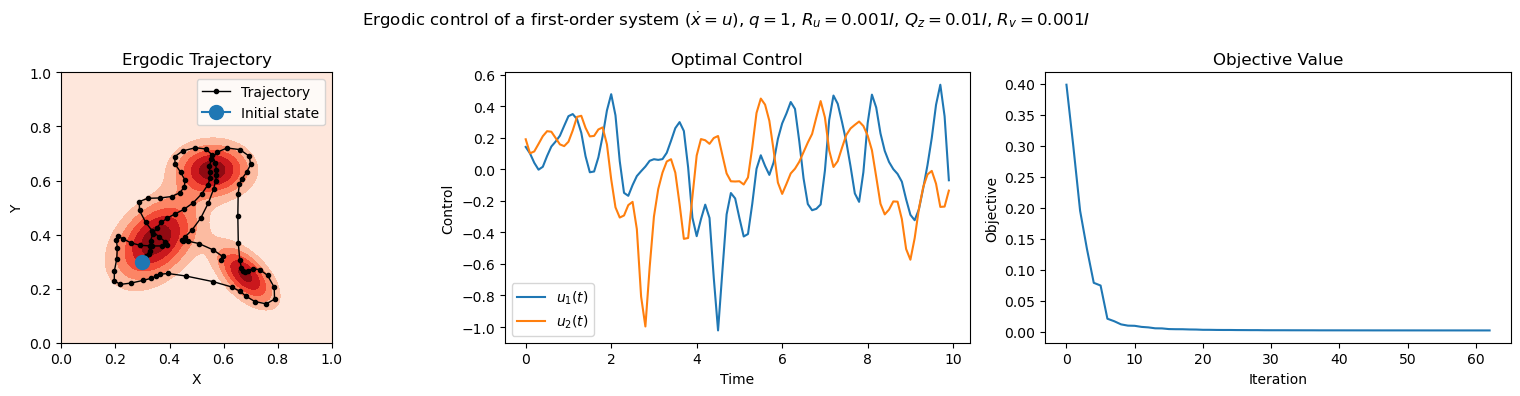

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Ergodic control of a first-order system ($\\dot{x} = u$), '
             '$q = 1$, $R_u = 0.001 I$, $Q_z = 0.01 I$, $R_v = 0.001 I$')

ax = axes[0]
ax.set_aspect('equal')
ax.set_xlim(0.0, L_list[0])
ax.set_ylim(0.0, L_list[1])
ax.contourf(grids_x, grids_y, pdf(grids).reshape(grids_x.shape), cmap='Reds')
ax.plot(np.hstack([x0[0], x_opt[:, 0]]), np.hstack([x0[1], x_opt[:, 1]]),
        linestyle='-', marker='o', color='k', markersize=3, linewidth=1, label='Trajectory')
ax.plot(x0[0], x0[1], marker='o', color='C0', markersize=10, label='Initial state')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Ergodic Trajectory')
ax.legend(loc=1)

ax = axes[1]
ax.plot(tlist, u_opt[:, 0], label='$u_1(t)$')
ax.plot(tlist, u_opt[:, 1], label='$u_2(t)$')
ax.set_xlabel('Time')
ax.set_ylabel('Control')
ax.set_title('Optimal Control')
ax.legend()

ax = axes[2]
ax.plot(np.arange(len(J_list)), J_list)
ax.set_xlabel('Iteration')
ax.set_ylabel('Objective')
ax.set_title('Objective Value')

plt.tight_layout()
plt.show()

## Problem 2

Generate an ergodic trajectory with the same specifications from the last problem, but with the system dynamics being a second-order system:

$$\ddot{x}(t) = f(x(t), u(t)) = u(t)$$

The system state is augmented to $s = [x, y, v_x, v_y]$ with $\dot{s} = [v_x, v_y, u_1, u_2]$, starting at rest from $[0.3, 0.3]$. The ergodic metric is evaluated over the position components only, so the ergodic gradient enters only the first two entries of $a(t)$. The Fourier basis setup, target distribution coefficients, and ergodic metric helpers are reused from Problem 1.

In [4]:
# second-order system: state s = [x, y, vx, vy], dynamics s_dot = [v, u]
x0_2 = np.array([0.3, 0.3, 0.0, 0.0])

A_mat_2 = np.zeros((4, 4))
A_mat_2[0, 2] = 1.0
A_mat_2[1, 3] = 1.0
B_mat_2 = np.zeros((4, 2))
B_mat_2[2, 0] = 1.0
B_mat_2[3, 1] = 1.0

R_u_2 = np.diag([0.001, 0.001])
Q_z_2 = np.diag([0.01, 0.01, 0.01, 0.01])
R_v_2 = np.diag([0.01, 0.01])
R_v_2_inv = np.linalg.inv(R_v_2)


def traj_sim_2(x0, ulist):
    # exact integration of the double integrator over each step
    x_traj = np.zeros((tsteps, 4))
    st = x0.copy()
    for t in range(tsteps):
        pos, vel = st[:2], st[2:]
        ut = ulist[t]
        st = np.hstack([pos + vel * dt + 0.5 * ut * dt**2, vel + ut * dt])
        x_traj[t] = st
    return x_traj


def total_cost_2(x_traj, u_traj):
    return q * ergodic_metric(x_traj[:, :2]) + np.sum((u_traj @ R_u_2) * u_traj) * dt


def ilqr_iter_2(x0, u_traj):
    x_traj = traj_sim_2(x0, u_traj)
    # the ergodic metric only depends on the position components
    a_list = np.hstack([erg_grad(x_traj[:, :2]), np.zeros((tsteps, 2))])
    b_list = 2.0 * u_traj @ R_u_2
    p1 = np.zeros(4)  # no terminal cost

    # linear dynamics: A, B constant -> the M blocks are constant in time
    M = np.block([
        [A_mat_2, -0.5 * B_mat_2 @ R_v_2_inv @ B_mat_2.T],
        [-2.0 * Q_z_2, -A_mat_2.T]
    ])

    def zp_dyn_list(t_list, zp_list):
        t_idx = np.clip((t_list / dt).astype(int), 0, tsteps - 1)
        m_vec = np.vstack([-0.5 * B_mat_2 @ R_v_2_inv @ b_list[t_idx].T, -a_list[t_idx].T])
        return M @ zp_list + m_vec

    # boundary conditions: z(0) = 0, p(T) = p1
    def zp_bc(zp_0, zp_T):
        return np.hstack([zp_0[:4], zp_T[4:] - p1])

    tlist = np.arange(tsteps) * dt
    res = solve_bvp(zp_dyn_list, zp_bc, tlist, np.zeros((8, tsteps)), max_nodes=200)
    zp_traj = res.sol(tlist).T
    z_traj = zp_traj[:, :4]
    p_traj = zp_traj[:, 4:]

    # v(t) = -0.5 * Rv^-1 * (B^T p + b_u)
    v_traj = -0.5 * (p_traj @ B_mat_2 + b_list) @ R_v_2_inv.T

    # directional derivative DJ(u).v = int(a_x.z + b_u.v)dt + p1.z(T)
    descent_dot = (np.sum(a_list * z_traj) + np.sum(b_list * v_traj)) * dt + p1 @ z_traj[-1]
    return v_traj, descent_dot


def run_ilqr_2(init_u_traj, max_iters=400, tol=1e-6, gamma0=0.01):
    u_traj = init_u_traj.copy()
    J_list = [total_cost_2(traj_sim_2(x0_2, u_traj), u_traj)]
    for it in range(max_iters):
        v_traj, descent_dot = ilqr_iter_2(x0_2, u_traj)

        # Armijo line search (small initial step keeps the trajectory in bounds)
        gamma, alpha, beta = gamma0, 1e-4, 0.5
        J_curr = J_list[-1]
        while True:
            u_new = u_traj + gamma * v_traj
            if total_cost_2(traj_sim_2(x0_2, u_new), u_new) <= J_curr + alpha * gamma * descent_dot:
                break
            gamma *= beta
            if gamma < 1e-10:
                break

        u_traj = u_traj + gamma * v_traj
        J_list.append(total_cost_2(traj_sim_2(x0_2, u_traj), u_traj))

        if abs(J_list[-1] - J_list[-2]) < tol:
            break

    return u_traj, np.array(J_list)


# initial control with zero-mean velocities, so the initial trajectory stays in bounds
tlist = np.arange(tsteps) * dt
init_u_traj_2 = np.stack([0.2 * np.cos(tlist), 0.2 * np.cos(2 * tlist)], axis=1)
u_opt_2, J_list_2 = run_ilqr_2(init_u_traj_2)
x_opt_2 = traj_sim_2(x0_2, u_opt_2)
print(f'Stopped after {len(J_list_2) - 1} iterations, objective J = {J_list_2[-1]:.6f}, '
      f'ergodic metric = {ergodic_metric(x_opt_2[:, :2]):.6f}')

Stopped after 296 iterations, objective J = 0.020679, ergodic metric = 0.018687


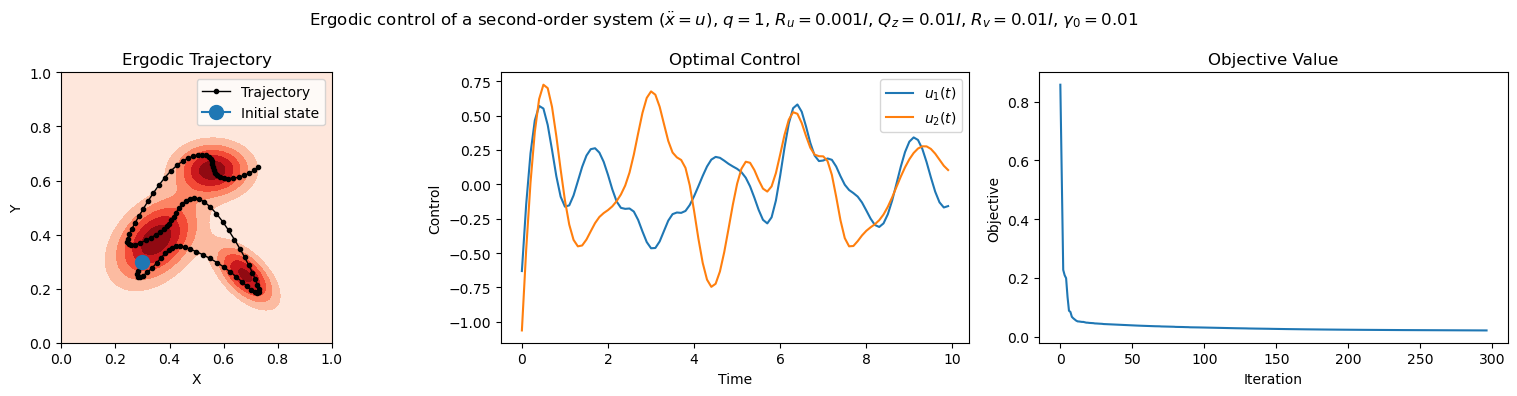

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Ergodic control of a second-order system ($\\ddot{x} = u$), '
             '$q = 1$, $R_u = 0.001 I$, $Q_z = 0.01 I$, $R_v = 0.01 I$, $\\gamma_0 = 0.01$')

ax = axes[0]
ax.set_aspect('equal')
ax.set_xlim(0.0, L_list[0])
ax.set_ylim(0.0, L_list[1])
ax.contourf(grids_x, grids_y, pdf(grids).reshape(grids_x.shape), cmap='Reds')
ax.plot(np.hstack([x0_2[0], x_opt_2[:, 0]]), np.hstack([x0_2[1], x_opt_2[:, 1]]),
        linestyle='-', marker='o', color='k', markersize=3, linewidth=1, label='Trajectory')
ax.plot(x0_2[0], x0_2[1], marker='o', color='C0', markersize=10, label='Initial state')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Ergodic Trajectory')
ax.legend(loc=1)

ax = axes[1]
ax.plot(tlist, u_opt_2[:, 0], label='$u_1(t)$')
ax.plot(tlist, u_opt_2[:, 1], label='$u_2(t)$')
ax.set_xlabel('Time')
ax.set_ylabel('Control')
ax.set_title('Optimal Control')
ax.legend()

ax = axes[2]
ax.plot(np.arange(len(J_list_2)), J_list_2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Objective')
ax.set_title('Objective Value')

plt.tight_layout()
plt.show()

## Problem 3

Generate an ergodic trajectory with the same specifications from the last problem, but with the system being a differential-drive vehicle and initial condition $[0.3, 0.3, \pi/2]$:

$$\begin{bmatrix} \dot{x} \\ \dot{y} \\ \dot{\theta} \end{bmatrix} = \begin{bmatrix} \cos(\theta)u_1 \\ \sin(\theta)u_1 \\ u_2 \end{bmatrix}$$

The ergodic metric is evaluated over the $x, y$ position of the robot only, so the ergodic gradient fills the first two entries of $a(t)$ and the $\theta$ entry is zero. Unlike Problems 1 and 2, the linearizations $A(t)$, $B(t)$ are time-varying along the trajectory (same expressions as in Homework 4), so the BVP dynamics matrix is rebuilt per time index. The Fourier basis setup and ergodic metric helpers are reused from Problem 1.

In [6]:
# differential-drive vehicle: state s = [x, y, theta]
x0_3 = np.array([0.3, 0.3, np.pi / 2.0])

R_u_3 = np.diag([0.001, 0.001])
Q_z_3 = np.diag([0.01, 0.01, 0.01])
R_v_3 = np.diag([0.01, 0.01])
R_v_3_inv = np.linalg.inv(R_v_3)


def dyn_3(st, ut):
    return np.array([np.cos(st[2]) * ut[0], np.sin(st[2]) * ut[0], ut[1]])


def get_A_3(st, ut):
    return np.array([
        [0.0, 0.0, -np.sin(st[2]) * ut[0]],
        [0.0, 0.0,  np.cos(st[2]) * ut[0]],
        [0.0, 0.0,  0.0]
    ])


def get_B_3(st, ut):
    return np.array([
        [np.cos(st[2]), 0.0],
        [np.sin(st[2]), 0.0],
        [0.0, 1.0]
    ])


def step_3(st, ut):
    # RK4 integration
    k1 = dyn_3(st, ut)
    k2 = dyn_3(st + 0.5 * dt * k1, ut)
    k3 = dyn_3(st + 0.5 * dt * k2, ut)
    k4 = dyn_3(st + dt * k3, ut)
    return st + dt / 6.0 * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def traj_sim_3(x0, ulist):
    x_traj = np.zeros((tsteps, 3))
    st = x0.copy()
    for t in range(tsteps):
        st = step_3(st, ulist[t])
        x_traj[t] = st
    return x_traj


def total_cost_3(x_traj, u_traj):
    return q * ergodic_metric(x_traj[:, :2]) + np.sum((u_traj @ R_u_3) * u_traj) * dt


def ilqr_iter_3(x0, u_traj):
    x_traj = traj_sim_3(x0, u_traj)
    # the ergodic metric only depends on the x, y position
    a_list = np.hstack([erg_grad(x_traj[:, :2]), np.zeros((tsteps, 1))])
    b_list = 2.0 * u_traj @ R_u_3
    p1 = np.zeros(3)  # no terminal cost

    # time-varying linearizations along the current trajectory
    A_list = np.zeros((tsteps, 3, 3))
    B_list = np.zeros((tsteps, 3, 2))
    for t_idx in range(tsteps):
        A_list[t_idx] = get_A_3(x_traj[t_idx], u_traj[t_idx])
        B_list[t_idx] = get_B_3(x_traj[t_idx], u_traj[t_idx])

    def zp_dyn(t, zp):
        t_idx = int(np.clip(t / dt, 0, tsteps - 1))
        At = A_list[t_idx]
        Bt = B_list[t_idx]

        M = np.block([
            [At, -0.5 * Bt @ R_v_3_inv @ Bt.T],
            [-2.0 * Q_z_3, -At.T]
        ])
        m_vec = np.hstack([-0.5 * Bt @ R_v_3_inv @ b_list[t_idx], -a_list[t_idx]])
        return M @ zp + m_vec

    def zp_dyn_list(t_list, zp_list):
        zp_dot_list = np.zeros((6, len(t_list)))
        for _i in range(len(t_list)):
            zp_dot_list[:, _i] = zp_dyn(t_list[_i], zp_list[:, _i])
        return zp_dot_list

    # boundary conditions: z(0) = 0, p(T) = p1
    def zp_bc(zp_0, zp_T):
        return np.hstack([zp_0[:3], zp_T[3:] - p1])

    tlist = np.arange(tsteps) * dt
    res = solve_bvp(zp_dyn_list, zp_bc, tlist, np.zeros((6, tsteps)), max_nodes=200)
    zp_traj = res.sol(tlist).T
    z_traj = zp_traj[:, :3]
    p_traj = zp_traj[:, 3:]

    # v(t) = -0.5 * Rv^-1 * (B(t)^T p + b_u)
    v_traj = np.zeros((tsteps, 2))
    for _i in range(tsteps):
        v_traj[_i] = -0.5 * R_v_3_inv @ (B_list[_i].T @ p_traj[_i] + b_list[_i])

    # directional derivative DJ(u).v = int(a_x.z + b_u.v)dt + p1.z(T)
    descent_dot = (np.sum(a_list * z_traj) + np.sum(b_list * v_traj)) * dt + p1 @ z_traj[-1]
    return v_traj, descent_dot


def run_ilqr_3(init_u_traj, max_iters=400, tol=1e-6, gamma0=0.01):
    u_traj = init_u_traj.copy()
    J_list = [total_cost_3(traj_sim_3(x0_3, u_traj), u_traj)]
    for it in range(max_iters):
        v_traj, descent_dot = ilqr_iter_3(x0_3, u_traj)

        # Armijo line search (small initial step keeps the trajectory in bounds)
        gamma, alpha, beta = gamma0, 1e-4, 0.5
        J_curr = J_list[-1]
        while True:
            u_new = u_traj + gamma * v_traj
            if total_cost_3(traj_sim_3(x0_3, u_new), u_new) <= J_curr + alpha * gamma * descent_dot:
                break
            gamma *= beta
            if gamma < 1e-10:
                break

        u_traj = u_traj + gamma * v_traj
        J_list.append(total_cost_3(traj_sim_3(x0_3, u_traj), u_traj))

        if abs(J_list[-1] - J_list[-2]) < tol:
            break

    return u_traj, np.array(J_list)


# constant initial control: a radius-0.2 circle centered at (0.5, 0.3), inside the bounds
init_u_traj_3 = np.tile(np.array([0.2, -1.0]), reps=(tsteps, 1))
u_opt_3, J_list_3 = run_ilqr_3(init_u_traj_3)
x_opt_3 = traj_sim_3(x0_3, u_opt_3)
print(f'Stopped after {len(J_list_3) - 1} iterations, objective J = {J_list_3[-1]:.6f}, '
      f'ergodic metric = {ergodic_metric(x_opt_3[:, :2]):.6f}')

Stopped after 358 iterations, objective J = 0.021199, ergodic metric = 0.007494


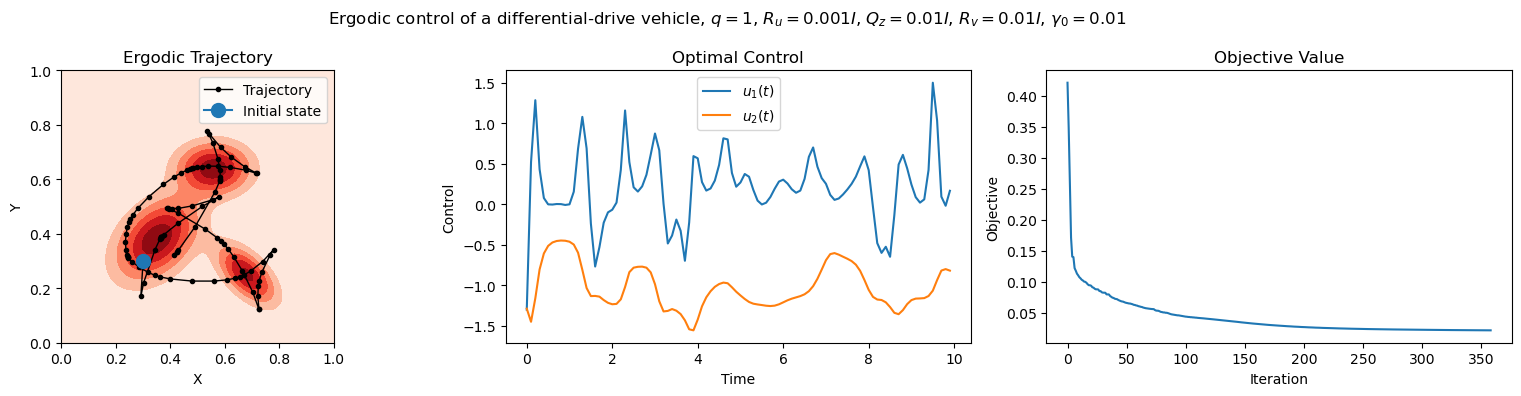

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Ergodic control of a differential-drive vehicle, '
             '$q = 1$, $R_u = 0.001 I$, $Q_z = 0.01 I$, $R_v = 0.01 I$, $\\gamma_0 = 0.01$')

ax = axes[0]
ax.set_aspect('equal')
ax.set_xlim(0.0, L_list[0])
ax.set_ylim(0.0, L_list[1])
ax.contourf(grids_x, grids_y, pdf(grids).reshape(grids_x.shape), cmap='Reds')
ax.plot(np.hstack([x0_3[0], x_opt_3[:, 0]]), np.hstack([x0_3[1], x_opt_3[:, 1]]),
        linestyle='-', marker='o', color='k', markersize=3, linewidth=1, label='Trajectory')
ax.plot(x0_3[0], x0_3[1], marker='o', color='C0', markersize=10, label='Initial state')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Ergodic Trajectory')
ax.legend(loc=1)

ax = axes[1]
ax.plot(tlist, u_opt_3[:, 0], label='$u_1(t)$')
ax.plot(tlist, u_opt_3[:, 1], label='$u_2(t)$')
ax.set_xlabel('Time')
ax.set_ylabel('Control')
ax.set_title('Optimal Control')
ax.legend()

ax = axes[2]
ax.plot(np.arange(len(J_list_3)), J_list_3)
ax.set_xlabel('Iteration')
ax.set_ylabel('Objective')
ax.set_title('Objective Value')

plt.tight_layout()
plt.show()